# What this notebook is doing (PNNL Skagit basin mask creation)

This notebook builds the Skagit sub-basin masks on the PNNL historical grid.
The main reason for doing this is that the PNNL precipitation files often do not carry usable lat/lon information directly, so I needed a separate mask file that lines up with the 450 x 450 PNNL grid.

The first cell finds a matching PNNL grid file that does have latitude and longitude, then rasterizes the Upper Skagit, Sauk, and Lower Skagit polygons onto that grid and saves the result as a mask NetCDF.
The later cells are just checks to confirm the mask looks right and that the region coverage is reasonable.

So this notebook is mainly a setup/utility notebook for creating the PNNL region mask used by later analysis.


In [ ]:

# ============================================================
# Build 3-region (HUC8) mask on the PNNL 450x450 grid
#
# Problem:
#   PNNL PREC_ACC_NC files often have NO lat/lon.
#   skagit_mask_pnnl_450x450.nc has only skagit_mask.
#
# Solution:
#   Auto-search for a "grid reference" NetCDF that contains lat/lon
#   (or XLAT/XLONG) on the SAME (y,x) grid, then rasterize polygons.
#
# Output:
#   skagit_huc8_3mask_pnnl_450x450.nc with:
#     mask(region,y,x) boolean
#     region coord = ["Upper Skagit","Sauk","Lower Skagit"]
#     latitude(y,x), longitude(y,x) if available
# ============================================================

from __future__ import annotations

from pathlib import Path
from glob import glob

import numpy as np
import xarray as xr
import pandas as pd


# ---------------- User config ----------------
BASE = Path("/data0/balaji24/data")
PNNL_HIST = BASE / "PNNL" / "historical"

BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

OUT_FILE = Path("/home/balaji24/skagit-met/analysis/skagit_huc8_3mask_pnnl_450x450.nc")

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

EXTRA_SEARCH_ROOTS = [
    BASE / "PNNL",
    BASE,
    Path("/home/balaji24/skagit-met/analysis"),
]


# ---------------- Helpers ----------------
def normalize_lon(lon):
    """Convert longitude to [-180, 180] while preserving shape."""
    return (((lon + 180.0) % 360.0) - 180.0)


def find_lat_lon_in_ds(ds: xr.Dataset):
    """
    Find lat/lon as either coords or data_vars.
    Returns (lat, lon) as xarray objects, or (None, None).
    """
    candidates_lat = [
        "lat", "latitude", "LAT", "Latitude",
        "nav_lat", "XLAT", "XLAT_M", "xlat"
    ]
    candidates_lon = [
        "lon", "longitude", "LON", "Longitude",
        "nav_lon", "XLONG", "XLONG_M", "xlong"
    ]

    lat_name = next((n for n in candidates_lat if (n in ds.coords or n in ds.data_vars)), None)
    lon_name = next((n for n in candidates_lon if (n in ds.coords or n in ds.data_vars)), None)

    if lat_name is None or lon_name is None:
        return None, None

    return ds[lat_name], ds[lon_name]


def to_2d_latlon(lat, lon):
    """
    Ensure lat/lon are 2D arrays.
    - If already 2D, return as-is.
    - If 1D (lat(y), lon(x)), broadcast to (y, x).
    """
    lat = lat.squeeze()
    lon = lon.squeeze()

    if lat.ndim == 2 and lon.ndim == 2:
        return lat, lon

    if lat.ndim == 1 and lon.ndim == 1:
        lon2d, lat2d = xr.broadcast(lon, lat)
        return lat2d, lon2d

    if lat.ndim == 1 and lon.ndim == 2:
        lat2d = xr.broadcast(lon, lat)[1]
        return lat2d, lon

    if lat.ndim == 2 and lon.ndim == 1:
        lon2d = xr.broadcast(lon, lat)[0]
        return lat, lon2d

    raise ValueError(f"Unsupported lat/lon shapes: lat.ndim={lat.ndim}, lon.ndim={lon.ndim}")


def quick_open_header(nc_path: Path) -> xr.Dataset:
    """
    Open only metadata/header-ish (no big reads).
    decode_times=False avoids time decoding overhead.
    """
    return xr.open_dataset(nc_path, engine="netcdf4", decode_times=False)


def looks_like_target_grid(lat2d, lon2d, expected_shape=None):
    """
    Optional sanity checks:
    - Must be 2D
    - If expected_shape known, must match
    """
    if lat2d.ndim != 2 or lon2d.ndim != 2:
        return False
    if expected_shape is not None:
        return tuple(lat2d.shape) == tuple(expected_shape) and tuple(lon2d.shape) == tuple(expected_shape)
    return True


def find_expected_pnnl_grid_shape():
    """
    Get (y,x) shape from ANY PREC_ACC_NC file (even though it lacks lat/lon).
    We only need its spatial shape to validate candidate grid files.
    """
    cand = sorted(glob(str(PNNL_HIST / "*" / "*PREC_ACC_NC*.nc")))
    if not cand:
        return None

    ds = xr.open_dataset(cand[0], engine="netcdf4", decode_times=False)
    # pick the precip var itself (will be time,y,x usually)
    v = next((vv for vv in ds.data_vars if "PREC_ACC_NC" in vv), None)
    if v is None:
        ds.close()
        return None

    da = ds[v]
    # remove time dim if present
    dims = [d for d in da.dims if d != "time"]
    shape = tuple(da.sizes[d] for d in dims)
    ds.close()

    # Many PNNL files are (y,x); if there are more dims, take last 2
    if len(shape) >= 2:
        return shape[-2], shape[-1]
    return None


def find_grid_ref_file(expected_shape=None):
    """
    Search for a NetCDF that contains lat/lon (or XLAT/XLONG) on the PNNL grid.
    """
    search_roots = [PNNL_HIST] + [p for p in EXTRA_SEARCH_ROOTS if p.exists()]

    # NetCDF patterns to scan (include common WRF/static names too)
    patterns = [
        "**/*.nc",
        "**/*.NC",
        "**/*.cdf",
    ]

    tried = 0
    for root in search_roots:
        for pat in patterns:
            for f in sorted(root.glob(pat)):
                # Avoid scanning a million files too slowly: skip obviously huge time-series
                # but still allow if it has lat/lon.
                if not f.is_file():
                    continue

                tried += 1
                try:
                    ds = quick_open_header(f)
                except Exception:
                    continue

                lat, lon = find_lat_lon_in_ds(ds)
                if lat is None or lon is None:
                    ds.close()
                    continue

                try:
                    lat2d, lon2d = to_2d_latlon(lat, lon)
                    lon2d = normalize_lon(lon2d)
                except Exception:
                    ds.close()
                    continue

                ok = looks_like_target_grid(lat2d, lon2d, expected_shape=expected_shape)
                ds.close()

                if ok:
                    return f, lat2d, lon2d

    raise ValueError(
        "Could not find ANY NetCDF under your search roots containing lat/lon on the PNNL grid.\n"
        f"Searched roots:\n  - " + "\n  - ".join(str(r) for r in search_roots) + "\n"
        "If you know the exact grid file path (WRF geo/static), set it manually and we’ll use it."
    )


def load_regions_gdf():
    """Load the 3 dominant HUC8 polygons, clipped to Skagit boundary."""
    import geopandas as gpd

    skagit = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8   = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    sub = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    if sub.empty:
        raise ValueError(
            f"No matching regions found. Expected Name in {REGION_NAMES}. "
            f"Check HUC8_GEO and Name field."
        )

    sub = gpd.overlay(sub, skagit, how="intersection")
    sub = sub[["Name", "geometry"]].copy()

    sub["Name"] = pd.Categorical(sub["Name"], categories=REGION_NAMES, ordered=True)
    sub = sub.sort_values("Name").reset_index(drop=True)
    return sub


def build_regionmask(regions_gdf):
    import regionmask

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )
    return regs


# ---------------- Main ----------------
def main():
    OUT_FILE.parent.mkdir(parents=True, exist_ok=True)

    print("[1/5] Loading polygons...")
    regions_gdf = load_regions_gdf()
    print("Regions:", list(regions_gdf["Name"].astype(str).values))

    print("[2/5] Detecting expected PNNL grid shape from PREC_ACC_NC...")
    expected = find_expected_pnnl_grid_shape()
    print("Expected PNNL spatial shape (y,x):", expected)

    print("[3/5] Searching for a grid reference NetCDF that contains lat/lon...")
    grid_file, lat2d, lon2d = find_grid_ref_file(expected_shape=expected)
    print("Found grid file:", grid_file)
    print("lat/lon shape:", tuple(lat2d.shape))

    # infer y/x dim names from lat2d
    ydim, xdim = lat2d.dims[-2], lat2d.dims[-1]
    print(f"Using dims: y={ydim}, x={xdim}")

    print("[4/5] Building region masks on that grid...")
    regs = build_regionmask(regions_gdf)
    rid = regs.mask(lon2d, lat2d)  # (y,x) region index 0..N-1 else nan

    mask_list = [(rid == i) for i in range(len(regs.names))]
    mask = xr.concat(mask_list, dim="region").astype(bool)
    mask = mask.assign_coords(region=np.array(regs.names, dtype=object))

    print("[5/5] Writing output:", OUT_FILE)
    out = xr.Dataset(
        data_vars=dict(
            mask=mask,
            latitude=lat2d.astype("float32"),
            longitude=lon2d.astype("float32"),
        ),
        attrs=dict(
            title="Skagit 3-region HUC8 mask on PNNL grid",
            regions="; ".join(REGION_NAMES),
            grid_file=str(grid_file),
        ),
    )

    encoding = {
        "mask": {"zlib": True, "complevel": 4},
        "latitude": {"zlib": True, "complevel": 4},
        "longitude": {"zlib": True, "complevel": 4},
    }
    out.to_netcdf(OUT_FILE, encoding=encoding)

    for r in regs.names:
        frac = float(out["mask"].sel(region=r).mean().values)
        print(f"  region={r:12s} covered_fraction={frac:.4f}")

    print(" Done.")


if __name__ == "__main__":
    main()


[1/5] Loading polygons...
Regions: ['Upper Skagit', 'Sauk', 'Lower Skagit']
[2/5] Detecting expected PNNL grid shape from PREC_ACC_NC...
Expected PNNL spatial shape (y,x): (450, 450)
[3/5] Searching for a grid reference NetCDF that contains lat/lon...
Found grid file: /data0/balaji24/data/PNNL/historical/SERDP6km.geo_em.d01.nc
lat/lon shape: (450, 450)
Using dims: y=south_north, x=west_east
[4/5] Building region masks on that grid...
[5/5] Writing output: /home/balaji24/skagit-met/analysis/skagit_huc8_3mask_pnnl_450x450.nc
  region=Upper Skagit covered_fraction=0.0007
  region=Sauk         covered_fraction=0.0003
  region=Lower Skagit covered_fraction=0.0001
 Done.


In [6]:
import xarray as xr
import numpy as np

m = xr.open_dataset("/home/balaji24/skagit-met/analysis/skagit_huc8_3mask_pnnl_450x450.nc")["mask"]

counts = {r: int(m.sel(region=r).sum().values) for r in m.region.values}
print("Cell counts:", counts, "total:", sum(counts.values()))

# Check overlap (should be 0)
overlap = (m.sum("region") > 1).sum().values
print("Overlapping cells:", int(overlap))

# Check coverage holes inside union (fine if >0, but good to know)
union = (m.sum("region") > 0)
print("Union cell count:", int(union.sum().values))

Cell counts: {np.str_('Upper Skagit'): 147, np.str_('Sauk'): 55, np.str_('Lower Skagit'): 25} total: 227
Overlapping cells: 0
Union cell count: 227


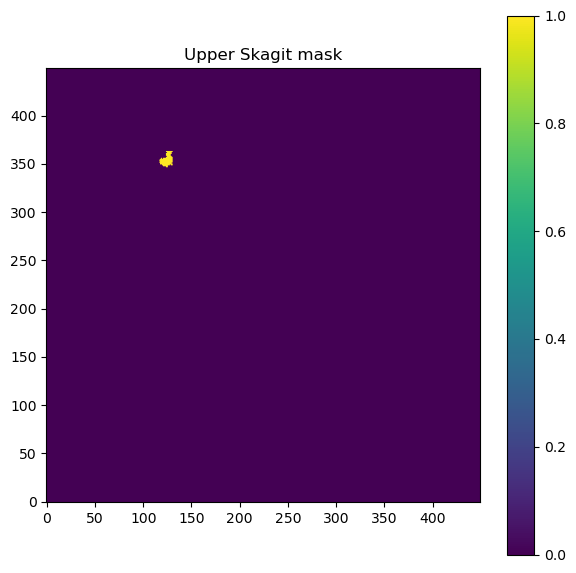

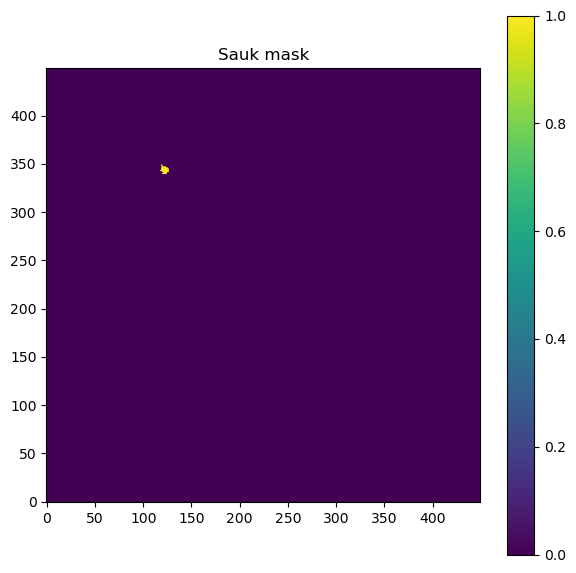

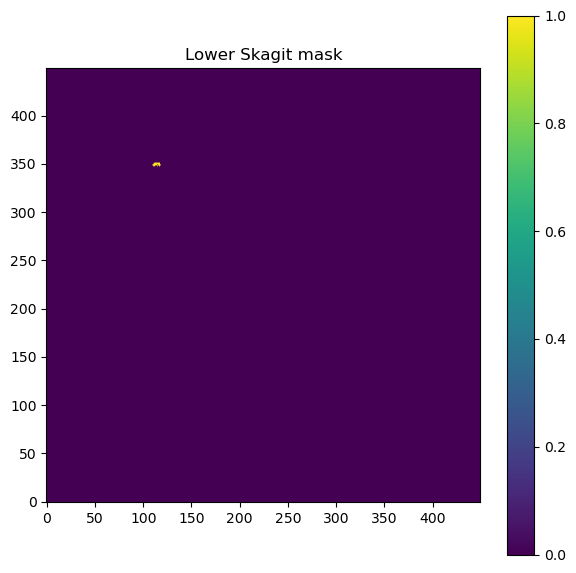

In [7]:
import matplotlib.pyplot as plt
import xarray as xr

ds = xr.open_dataset("/home/balaji24/skagit-met/analysis/skagit_huc8_3mask_pnnl_450x450.nc")
m = ds["mask"]

plt.figure(figsize=(7,7))
plt.imshow(m.sel(region="Upper Skagit"), origin="lower")
plt.title("Upper Skagit mask")
plt.colorbar()
plt.show()

plt.figure(figsize=(7,7))
plt.imshow(m.sel(region="Sauk"), origin="lower")
plt.title("Sauk mask")
plt.colorbar()
plt.show()

plt.figure(figsize=(7,7))
plt.imshow(m.sel(region="Lower Skagit"), origin="lower")
plt.title("Lower Skagit mask")
plt.colorbar()
plt.show()

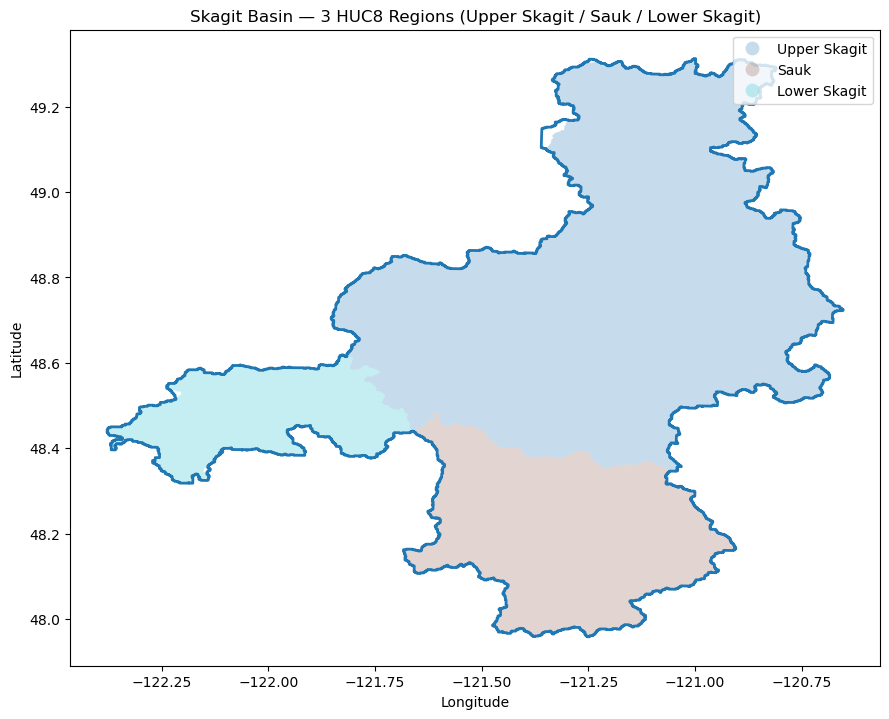

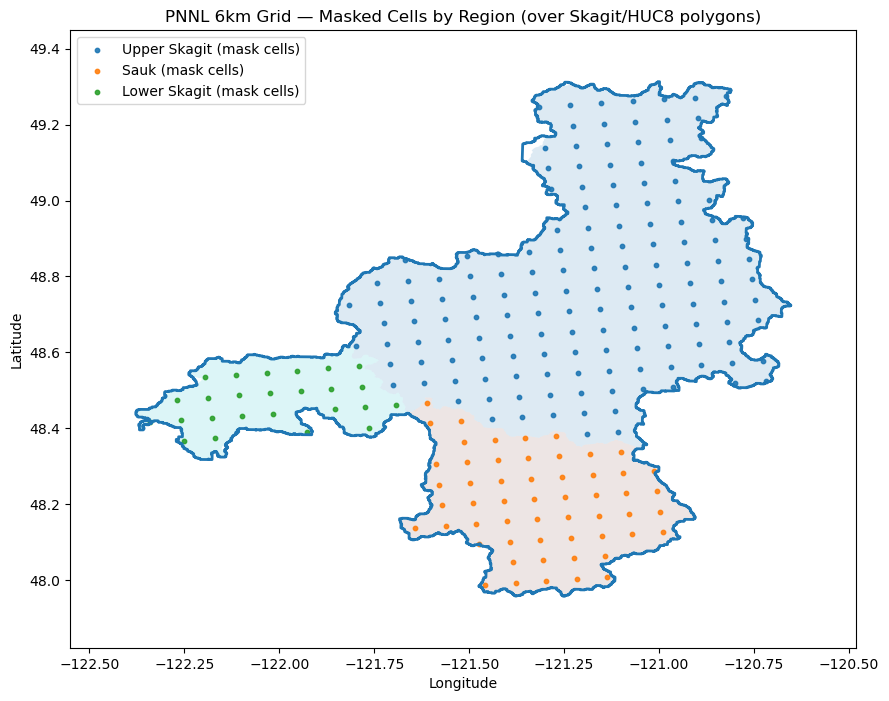

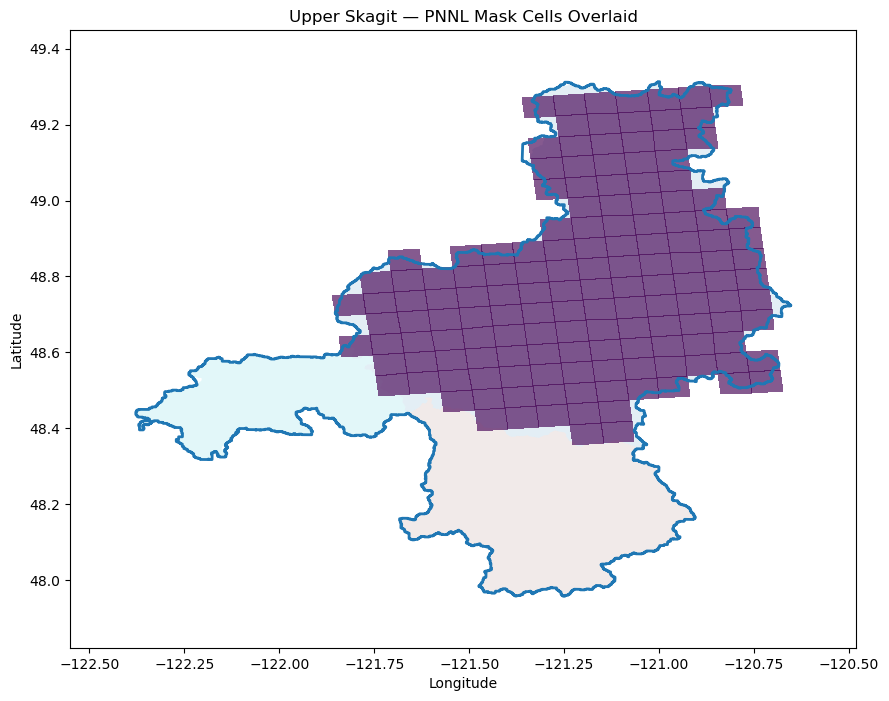

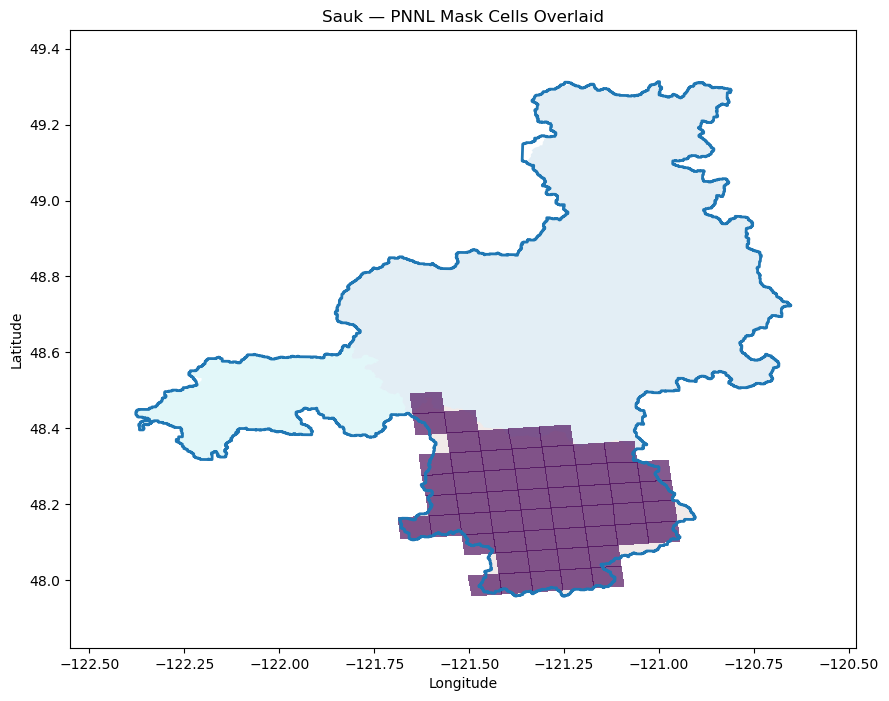

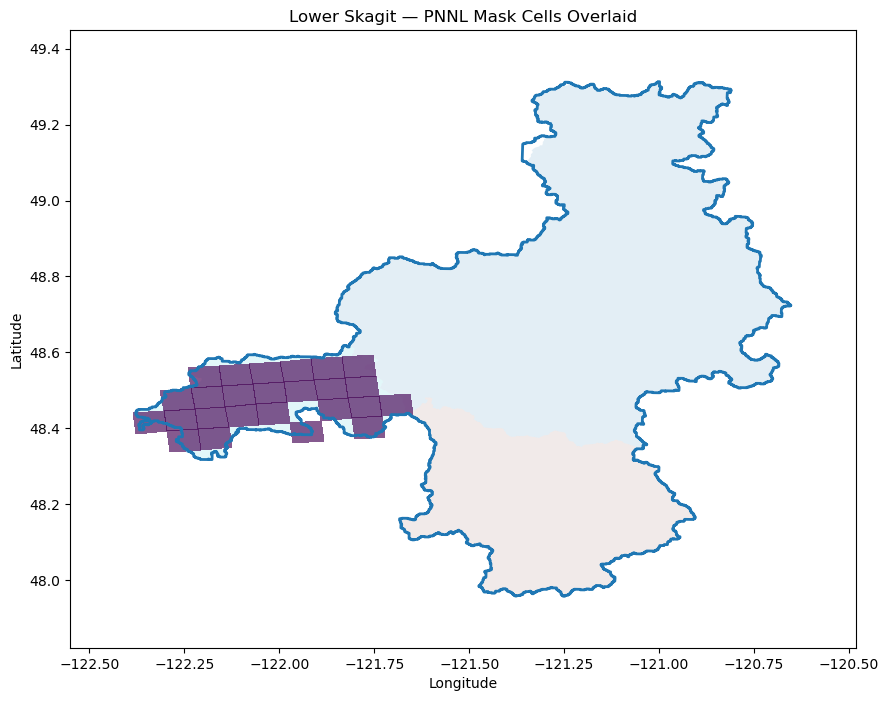

In [ ]:
# Visualize Skagit + 3 HUC8 regions + PNNL 3-region mask cells on a map

from pathlib import Path
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt

# ---------------- Paths ----------------
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

MASK_NC = Path("/home/balaji24/skagit-met/analysis/skagit_huc8_3mask_pnnl_450x450.nc")
GRID_NC = Path("/data0/balaji24/data/PNNL/historical/SERDP6km.geo_em.d01.nc")

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

# ---------------- Helpers ----------------
def find_lat_lon_vars(ds):
    # common WRF/geo_em names
    lat_candidates = ["XLAT_M", "XLAT", "lat", "latitude", "LAT"]
    lon_candidates = ["XLONG_M", "XLONG", "lon", "longitude", "LON"]

    lat_name = next((n for n in lat_candidates if (n in ds.data_vars or n in ds.coords)), None)
    lon_name = next((n for n in lon_candidates if (n in ds.data_vars or n in ds.coords)), None)

    if lat_name is None or lon_name is None:
        raise ValueError(
            f"Could not find lat/lon in grid file. "
            f"vars={list(ds.data_vars)} coords={list(ds.coords)}"
        )
    return lat_name, lon_name

def to_2d(da):
    # drop time if present and squeeze singleton dims
    if "time" in da.dims:
        da = da.isel(time=0)
    for d in list(da.dims):
        if da.sizes.get(d, 1) == 1:
            da = da.isel({d: 0})
    return da

def normalize_lon(lon2d):
    # convert to [-180,180] if needed
    x = lon2d.copy()
    if float(x.max()) > 180:
        x = ((x + 180) % 360) - 180
    return x

# ---------------- Load polygons ----------------
skagit = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
huc8   = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
if huc8_3.empty:
    raise ValueError(f"Could not find Name in {REGION_NAMES}. Check HUC8_GEO and field 'Name'.")

# clip to Skagit boundary so it looks clean
huc8_3 = gpd.overlay(huc8_3, skagit, how="intersection")
huc8_3["Name"] = gpd.pd.Categorical(huc8_3["Name"], categories=REGION_NAMES, ordered=True)
huc8_3 = huc8_3.sort_values("Name").reset_index(drop=True)

# ---------------- Load mask + grid ----------------
mask_ds = xr.open_dataset(MASK_NC)
m = mask_ds["mask"]  # dims: region, y, x (boolean or 0/1)

grid_ds = xr.open_dataset(GRID_NC)
lat_name, lon_name = find_lat_lon_vars(grid_ds)
lat2d = to_2d(grid_ds[lat_name])
lon2d = to_2d(grid_ds[lon_name])
lon2d = normalize_lon(lon2d)

# Align dims: mask dims names might differ from lat2d dims (south_north/west_east)
lat_np = np.asarray(lat2d)
lon_np = np.asarray(lon2d)

# ---------------- Plot 1: Polygons (nice clean region map) ----------------
fig, ax = plt.subplots(figsize=(9, 9))

# Skagit outline
skagit.boundary.plot(ax=ax, linewidth=2)

# Region polygons filled
huc8_3.plot(ax=ax, column="Name", alpha=0.25, legend=True)

ax.set_title("Skagit Basin — 3 HUC8 Regions (Upper Skagit / Sauk / Lower Skagit)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

# ---------------- Plot 2: Polygons + Mask cells overlaid ----------------
fig, ax = plt.subplots(figsize=(9, 9))

# Basemap layers
huc8_3.plot(ax=ax, column="Name", alpha=0.15, legend=False)
skagit.boundary.plot(ax=ax, linewidth=2)

# Plot mask cell centers (scatter) per region
for r in REGION_NAMES:
    if r not in m["region"].values.astype(str):
        # mask_ds region values might be np.str_ objects
        # so compare by string:
        pass
    # robust select:
    sel = m.sel(region=r) if r in list(m["region"].values) else m.sel(region=str(r))

    mask_np = np.asarray(sel).astype(bool)
    yy, xx = np.where(mask_np)
    ax.scatter(
        lon_np[yy, xx],
        lat_np[yy, xx],
        s=10,
        label=f"{r} (mask cells)",
        alpha=0.9
    )

# zoom tightly to Skagit region (based on boundary)
minx, miny, maxx, maxy = skagit.total_bounds
padx = (maxx - minx) * 0.10
pady = (maxy - miny) * 0.10
ax.set_xlim(minx - padx, maxx + padx)
ax.set_ylim(miny - pady, maxy + pady)

ax.set_title("PNNL 6km Grid — Masked Cells by Region (over Skagit/HUC8 polygons)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

# ---------------- Plot 3 (optional): Heatmap-style masks per region ----------------
# This makes it obvious where the selected cells are, but keeps the view zoomed.
for r in REGION_NAMES:
    fig, ax = plt.subplots(figsize=(9, 9))
    huc8_3.plot(ax=ax, column="Name", alpha=0.12, legend=False)
    skagit.boundary.plot(ax=ax, linewidth=2)

    sel = m.sel(region=r) if r in list(m["region"].values) else m.sel(region=str(r))
    mask_np = np.asarray(sel).astype(float)
    mask_np[mask_np == 0] = np.nan  # show only selected cells

    # pcolormesh on lat/lon grid
    ax.pcolormesh(lon_np, lat_np, mask_np, shading="auto", alpha=0.65)

    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)

    ax.set_title(f"{r} — PNNL Mask Cells Overlaid")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()
    plt.show()

# Close files
mask_ds.close()
grid_ds.close()
